**Objective**

Perform exploratory analysis on the cleaned metadata to understand:

Dataset composition
Missing values
Class distributions
Demographic distributions (where available)
Basic descriptive statistics

Input: data/processed/cleaned_metadata.csv

Output: 
reports/figures/

reports/eda_summary.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
PROJECT_DIR = Path("/workspaces/DBA-ai-trust-score-framework-Interim")

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
REPORT_DIR = PROJECT_DIR / "reports"
FIGURE_DIR = REPORT_DIR / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
metadata = pd.read_csv(
    PROCESSED_DIR / "cleaned_metadata.csv"
)

metadata.head()

,age,gender,race,service_test,file_name,dataset,image_id,left_eye_react,right_eye_react,label
0,4.0,0.0,3.0,False,fairface_00000.jpg,FairFace,71293.5,Unknown,Unknown,Unknown
1,1.0,1.0,5.0,False,fairface_00001.jpg,FairFace,71293.5,Unknown,Unknown,Unknown
2,2.0,1.0,0.0,False,fairface_00002.jpg,FairFace,71293.5,Unknown,Unknown,Unknown
3,3.0,1.0,0.0,False,fairface_00003.jpg,FairFace,71293.5,Unknown,Unknown,Unknown
4,2.0,0.0,5.0,True,fairface_00004.jpg,FairFace,71293.5,Unknown,Unknown,Unknown


In [4]:
print("Rows :", metadata.shape[0])
print("Columns :", metadata.shape[1])

metadata.info()

Rows : 2400
Columns : 10
<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              2400 non-null   float64
 1   gender           2400 non-null   float64
 2   race             2400 non-null   float64
 3   service_test     2400 non-null   str    
 4   file_name        2400 non-null   str    
 5   dataset          2400 non-null   str    
 6   image_id         2400 non-null   float64
 7   left_eye_react   2400 non-null   str    
 8   right_eye_react  2400 non-null   str    
 9   label            2400 non-null   str    
dtypes: float64(4), str(6)
memory usage: 366.9 KB


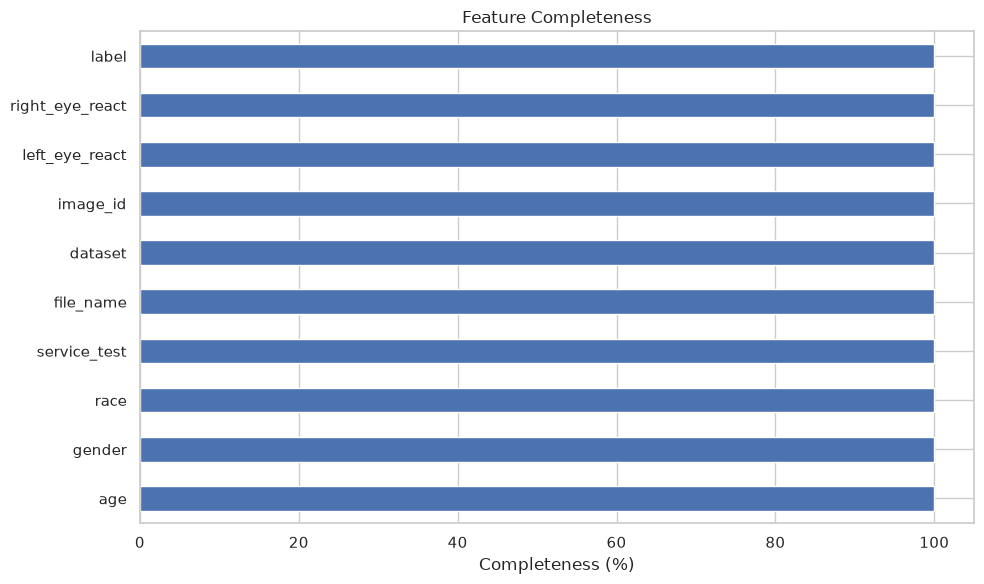

In [5]:
completeness = (metadata.notnull().mean() * 100).sort_values()

plt.figure(figsize=(10,6))

completeness.plot(kind="barh")

plt.xlabel("Completeness (%)")
plt.title("Feature Completeness")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "feature_completeness.png",
    dpi=300
)

plt.show()

In [6]:
stats = metadata.describe(include="all").T

stats.to_csv(
    REPORT_DIR/"eda_summary.csv"
)

stats

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,2400.0,NaN,NaN,NaN,3.201667,1.088879,0.0,3.0,3.0,3.0,8.0
gender,2400.0,NaN,NaN,NaN,0.189167,0.391723,0.0,0.0,0.0,0.0,1.0
race,2400.0,NaN,NaN,NaN,2.957083,1.252356,0.0,3.0,3.0,3.0,6.0
service_test,2400,3,Unknown,1400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
file_name,2400,2400,fairface_00000.jpg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,2400,3,FairFace,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
image_id,2400.0,NaN,NaN,NaN,69881.719583,23666.577721,127.0,71293.5,71293.5,71293.5,126475.0
left_eye_react,2400,998,Unknown,1400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
right_eye_react,2400,998,Unknown,1400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,2400,3,Unknown,1400,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
metadata["dataset"].value_counts()

dataset
FairFace             1000
Driver Drowsiness    1000
CelebA                400
Name: count, dtype: int64

/tmp/ipykernel_81559/2420473114.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


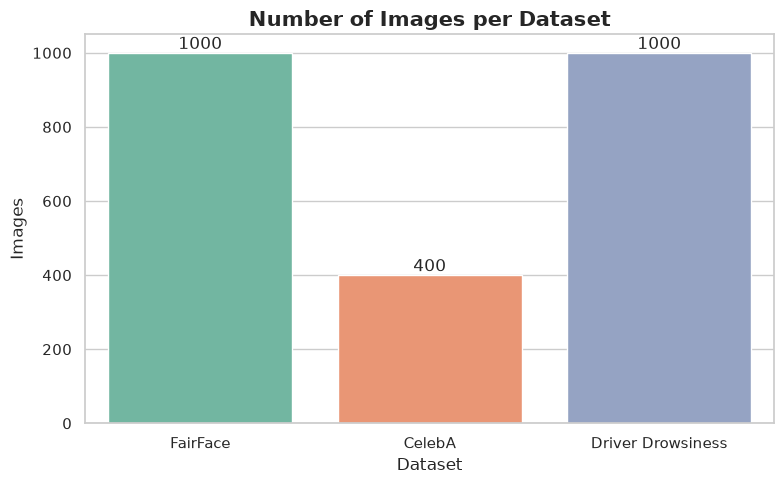

In [13]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=metadata,
    x="dataset",
    palette="Set2"
)

plt.title(
    "Number of Images per Dataset",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Dataset")
plt.ylabel("Images")

for p in ax.patches:

    ax.annotate(
        f"{int(p.get_height())}",
        (
            p.get_x()+p.get_width()/2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

____________________Fairface EDA______________________

In [24]:
fairface = metadata[
    metadata["dataset"]=="FairFace"
].copy()

print(fairface.shape)

(1000, 10)


In [26]:
fairface["gender"] = fairface["gender"].astype(int)
fairface["race"] = fairface["race"].astype(int)
fairface["age"] = fairface["age"].astype(int)

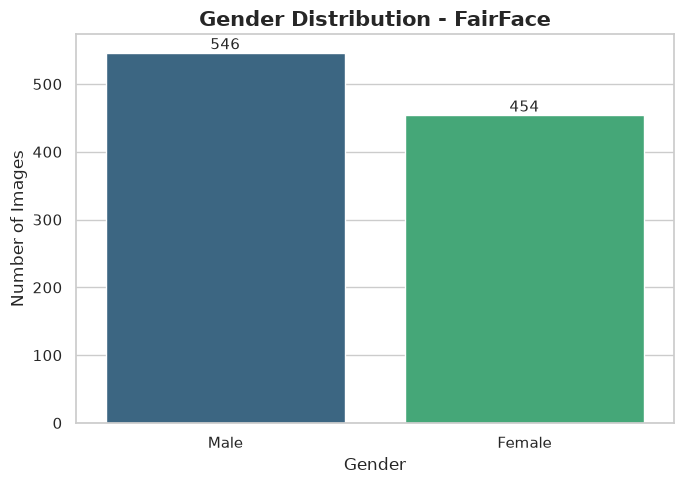

In [28]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=fairface,
    x="Gender",
    hue="Gender",          # fixes the seaborn deprecation warning
    palette="viridis",
    legend=False
)

plt.title(
    "Gender Distribution - FairFace",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Number of Images")

for p in ax.patches:

    ax.annotate(
        str(int(p.get_height())),
        (
            p.get_x()+p.get_width()/2,
            p.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

plt.show()

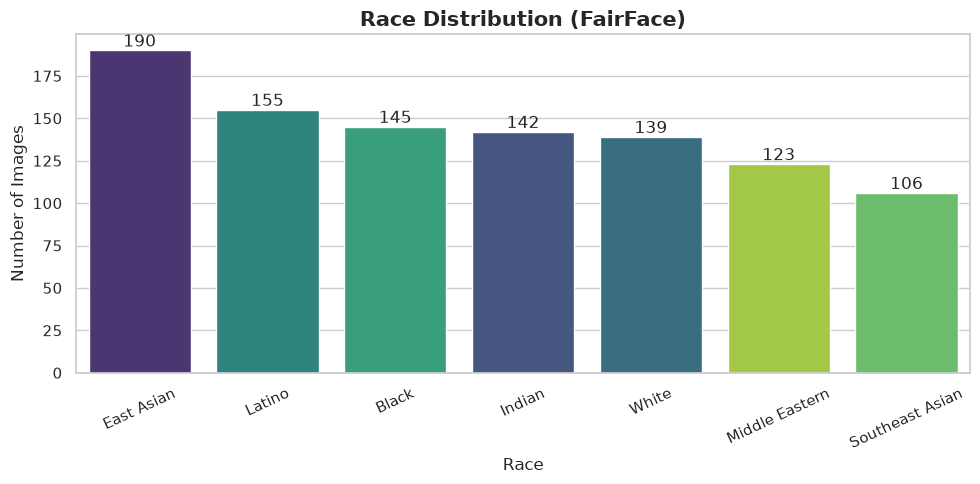

In [29]:
race_map = {

0:"White",
1:"Black",
2:"Latino",
3:"East Asian",
4:"Southeast Asian",
5:"Indian",
6:"Middle Eastern"

}

fairface["Race"] = fairface["race"].map(race_map)

plt.figure(figsize=(10,5))

ax = sns.countplot(

    data=fairface,

    x="Race",

    hue="Race",

    order=fairface["Race"].value_counts().index,

    palette="viridis",

    legend=False

)

plt.title(
    "Race Distribution (FairFace)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Race")
plt.ylabel("Number of Images")

plt.xticks(rotation=25)

for p in ax.patches:

    ax.annotate(
        str(int(p.get_height())),
        (
            p.get_x()+p.get_width()/2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR/"fairface_race_distribution.png",
    dpi=300
)

plt.show()

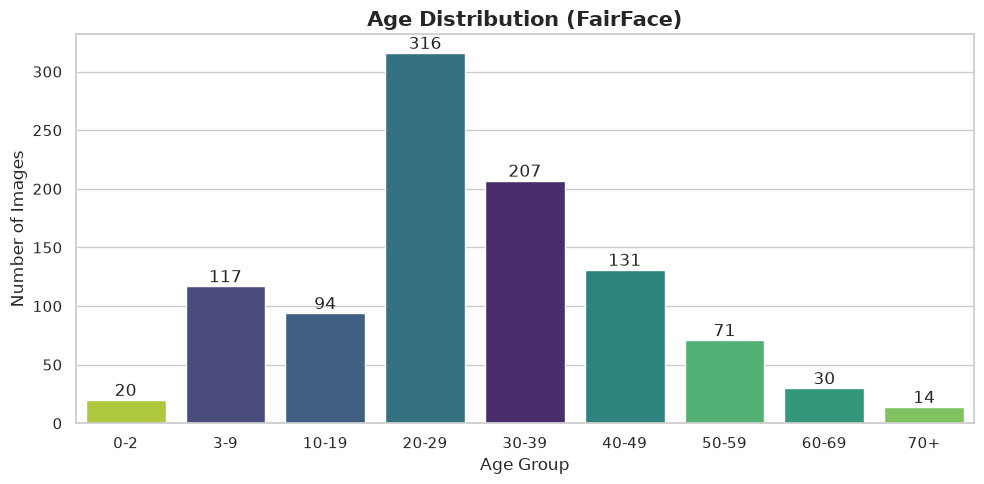

In [30]:
age_map = {

0:"0-2",

1:"3-9",

2:"10-19",

3:"20-29",

4:"30-39",

5:"40-49",

6:"50-59",

7:"60-69",

8:"70+"

}

fairface["Age Group"] = fairface["age"].map(age_map)

plt.figure(figsize=(10,5))

ax = sns.countplot(

    data=fairface,

    x="Age Group",

    hue="Age Group",

    order=list(age_map.values()),

    palette="viridis",

    legend=False

)

plt.title(
    "Age Distribution (FairFace)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Number of Images")

for p in ax.patches:

    ax.annotate(

        str(int(p.get_height())),

        (

            p.get_x()+p.get_width()/2,

            p.get_height()

        ),

        ha="center",

        va="bottom"

    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR/"fairface_age_distribution.png",
    dpi=300
)

plt.show()

__________________________________Driver Drowsiness Analysis________________________

In [31]:
driver = metadata[
    metadata["dataset"]=="Driver Drowsiness"
].copy()

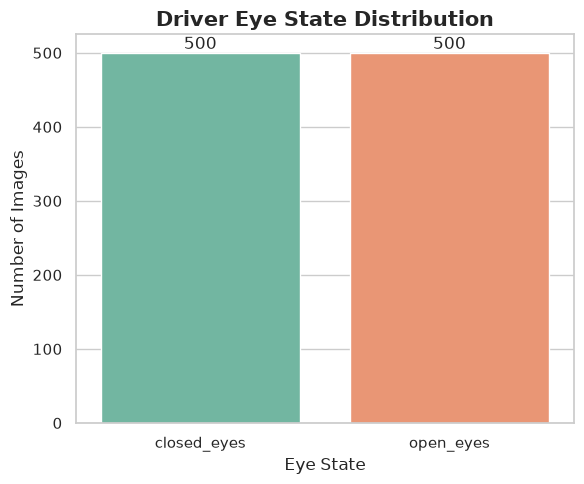

In [32]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=driver,
    x="label",
    hue="label",
    palette="Set2",
    legend=False
)

plt.title(
    "Driver Eye State Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Eye State")
plt.ylabel("Number of Images")

for p in ax.patches:

    ax.annotate(
        str(int(p.get_height())),
        (
            p.get_x()+p.get_width()/2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR/"driver_eye_distribution.png",
    dpi=300
)

plt.show()

_______________________________CelebA Analysis_____________________

In [33]:
celeba = metadata[
    metadata["dataset"]=="CelebA"
].copy()

In [34]:
summary = pd.DataFrame({

    "Dataset":[
        "FairFace",
        "Driver Drowsiness",
        "CelebA"
    ],

    "Images":[
        len(fairface),
        len(driver),
        len(celeba)
    ]

})

summary

,Dataset,Images
0,FairFace,1000
1,Driver Drowsiness,1000
2,CelebA,400


In [36]:
eda_summary = pd.DataFrame({

    "Metric":[

        "Total Images",

        "Datasets",

        "FairFace Images",

        "Driver Drowsiness Images",

        "CelebA Images"

    ],

    "Value":[

        len(metadata),

        metadata["dataset"].nunique(),

        len(fairface),

        len(driver),

        len(celeba)

    ]

})

eda_summary.to_csv(

    REPORT_DIR/"eda_summary.csv",

    index=False

)

eda_summary

,Metric,Value
0,Total Images,2400
1,Datasets,3
2,FairFace Images,1000
3,Driver Drowsiness Images,1000
4,CelebA Images,400
